# **Diabetes Risk FCNN**
Elizabeth Davis  
10/21/2025



### **Step 1: Setup & Controls**
We install the required packages, set seeds for reproducibility, and define all hyperparameters (folds, learning rate, oversampling ratio, etc.).

In [ ]:
#@title **Step 1: Setup & Controls**
!pip -q install scikit-learn torch matplotlib pandas numpy kagglehub
import os, random, numpy as np, pandas as pd, torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print('device:',DEVICE)
KFOLDS=5; USE_QUANTILE=True; USE_PCA=True; PCA_VARIANCE=0.95;
OVERSAMPLE_RATIO=3.0; LOSS='bce'; MAX_EPOCHS=150; PATIENCE=25;
LR=1e-3; WD=1e-5; CALIBRATE=True; LOCKED_THRESH=0.255

device: cuda


### **Step 2: Load Data**
We load the CDC Diabetes Health Indicators dataset directly from local upload to files directory. This ensures reproducibility and easy access to the dataset.

In [ ]:
#@title **Step 2: Load Data (Local Upload to Colab Files Directory)**

import pandas as pd

# Read diabetes.csv file directly
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
print("First 5 rows:")
print(df.head())

Shape: (253680, 22)
First 5 rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1

### **Step 3: Preprocessing**
We merge prediabetes into the positive class (so the target is binary).
Then we apply **QuantileTransformer** to handle skewed distributions and optional PCA to reduce noise (keeping 95% variance).
Finally, we split into training, validation, and test sets.

In [ ]:
#@title **Step 3: Preprocess (merge class 2, transform, PCA)**
target='Diabetes_012' if 'Diabetes_012' in df.columns else 'Diabetes_binary'
df2=df.copy()
if target=='Diabetes_012': df2[target]=df2[target].replace(2,1)
y=df2[target].astype(int).values
X=df2.drop(columns=[target]).apply(pd.to_numeric,errors='coerce').fillna(df2.median(numeric_only=True))
X_tr,X_tmp,y_tr,y_tmp=train_test_split(X,y,test_size=0.30,stratify=y,random_state=SEED)
X_val,X_te,y_val,y_te=train_test_split(X_tmp,y_tmp,test_size=0.50,stratify=y_tmp,random_state=SEED)
if USE_QUANTILE:
    transformer=QuantileTransformer(output_distribution='normal',random_state=SEED)
    X_tr=transformer.fit_transform(X_tr); X_val=transformer.transform(X_val); X_te=transformer.transform(X_te)
else:
    scaler=StandardScaler().fit(X_tr); X_tr=scaler.transform(X_tr); X_val=scaler.transform(X_val); X_te=scaler.transform(X_te)
if USE_PCA:
    pca=PCA(n_components=PCA_VARIANCE,svd_solver='full',random_state=SEED)
    X_tr=pca.fit_transform(X_tr); X_val=pca.transform(X_val); X_te=pca.transform(X_te)
    print('PCA components:', X_tr.shape[1])
print('splits:',X_tr.shape,X_val.shape,X_te.shape); print('class balance (train):',np.bincount(y_tr))

PCA components: 17
splits: (177576, 17) (38052, 17) (38052, 17)
class balance (train): [149592  27984]


### **Step 4: Define Compact Neural Network**
We use a fully connected neural network with BatchNorm and Dropout to improve generalization and stability.

In [ ]:
#@title **Step 4: Define Compact FCNN**
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
class MLP(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(64,32),  nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32,1))
    def forward(self,x): return self.net(x).squeeze(1)

### **Step 5: Training Helpers**
We oversample the positive class (3:1) to address imbalance. We use **weighted BCE** loss and early stopping on validation AUC.
This ensures the model doesn’t just predict negatives.

In [ ]:
#@title **Step 5: Train helpers**
class FocalLoss(nn.Module):
    def __init__(self,alpha=1.0,gamma=2.0):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self,inputs,targets):
        bce=nn.functional.binary_cross_entropy_with_logits(inputs,targets,reduction='none')
        pt=torch.exp(-bce); return (self.alpha*((1-pt)**self.gamma)*bce).mean()
def oversample_ratio(Xa,ya,ratio=3.0,seed=SEED):
    np.random.seed(seed); ya=np.asarray(ya)
    pos_idx=np.where(ya==1)[0]; neg_idx=np.where(ya==0)[0]
    if len(pos_idx)==0 or len(neg_idx)==0: return Xa,ya
    n_pos=int(ratio*len(neg_idx)); pos_resamp=np.random.choice(pos_idx,size=max(n_pos,len(pos_idx)),replace=True)
    idx=np.concatenate([pos_resamp,neg_idx]); np.random.shuffle(idx); return Xa[idx],ya[idx]
def train_one_fold(Xtrain,ytrain,Xvalid,yvalid,fold_id,save_name):
    model=MLP(Xtrain.shape[1]).to(DEVICE)
    pos,neg=(ytrain==1).sum(),(ytrain==0).sum()
    pos_w=torch.tensor([neg/max(pos,1)],dtype=torch.float32,device=DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pos_w) if LOSS=='bce' else FocalLoss()
    opt=torch.optim.Adam(model.parameters(),lr=LR,weight_decay=WD)
    Xb,yb=oversample_ratio(Xtrain,ytrain,ratio=OVERSAMPLE_RATIO,seed=SEED+fold_id)
    tr_ds=TensorDataset(torch.tensor(Xb,dtype=torch.float32),torch.tensor(yb,dtype=torch.float32))
    va_ds=TensorDataset(torch.tensor(Xvalid,dtype=torch.float32),torch.tensor(yvalid,dtype=torch.float32))
    tr=DataLoader(tr_ds,batch_size=1024,shuffle=True); va=DataLoader(va_ds,batch_size=4096)
    best_auc,stale=-1,0
    for ep in range(1,MAX_EPOCHS+1):
        model.train()
        for xb,yb in tr:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        model.eval(); ys,ps=[],[]
        with torch.no_grad():
            for xb,yb in va:
                pr=torch.sigmoid(model(xb.to(DEVICE)))
                ys.append(yb.numpy()); ps.append(pr.cpu().numpy())
        yv,pv=np.concatenate(ys),np.concatenate(ps)
        auc=roc_auc_score(yv,pv)
        if auc>best_auc: best_auc,stale=auc,0; torch.save(model.state_dict(),save_name)
        else: stale+=1
        if stale>=PATIENCE: break
    print('best_val_auc (fold',fold_id,'):',best_auc)

### **Step 6: Cross-Validation Ensemble + Calibration**
We train 5 folds and average their predictions for stability.
Then we use Platt scaling (logistic regression) for probability calibration.

In [ ]:
#@title **Step 6: K-fold training + calibration**
skf=StratifiedKFold(n_splits=KFOLDS,shuffle=True,random_state=SEED)
fold=0
for tr_idx,va_idx in skf.split(X_tr,y_tr):
    Xtr,Xva=X_tr[tr_idx],X_tr[va_idx]; ytr,yva=y_tr[tr_idx],y_tr[va_idx]
    train_one_fold(Xtr,ytr,Xva,yva,fold,f'best_model_fold{fold}.pt'); fold+=1
def load_fold_models():
    models=[]
    for f in range(KFOLDS):
        m=MLP(X_tr.shape[1]).to(DEVICE)
        m.load_state_dict(torch.load(f'best_model_fold{f}.pt',map_location=DEVICE))
        m.eval(); models.append(m)
    return models
models=load_fold_models()
with torch.no_grad():
    va_tensor=torch.tensor(X_val,dtype=torch.float32)
    probs=[torch.sigmoid(m(va_tensor.to(DEVICE))).cpu().numpy().reshape(-1) for m in models]
    p_val_raw=np.mean(np.vstack(probs),axis=0)
calibrator=None
if CALIBRATE:
    calibrator=LogisticRegression(max_iter=200,solver='lbfgs').fit(p_val_raw.reshape(-1,1),y_val)
    p_val=calibrator.predict_proba(p_val_raw.reshape(-1,1))[:,1]
else:
    p_val=p_val_raw.copy()
print('val AUC (calibrated):', round(roc_auc_score(y_val, p_val),3))

best_val_auc (fold 0 ): 0.8034079663235576
best_val_auc (fold 1 ): 0.8011063305521047
best_val_auc (fold 2 ): 0.8040428932286275
best_val_auc (fold 3 ): 0.8017504710003424
best_val_auc (fold 4 ): 0.8014223153912099
val AUC (calibrated): 0.805


### **Step 7: Final Test Evaluation**
We evaluate the ensemble on the test set with the locked MCC threshold (0.255).
This threshold gave the best balance: high recall (\~70%) while keeping precision acceptable (\~35%).

== Final Locked Results ==
Threshold: 0.255
Accuracy: 0.748
Precision: 0.35
Recall: 0.699
F1: 0.466
AUC: 0.807
Brier: 0.115
Confusion Matrix:
 [[24276  7779]
 [ 1807  4190]]


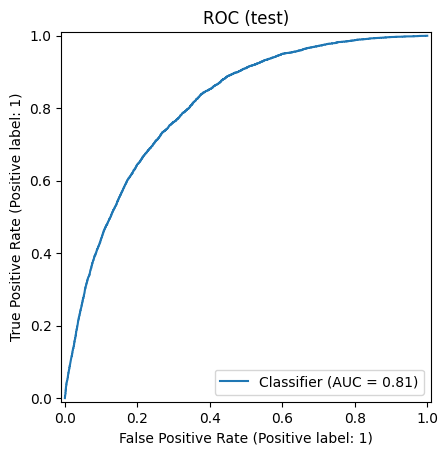

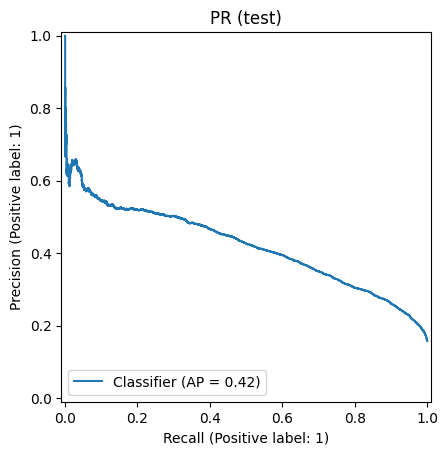

In [ ]:
#@title **Step 7: Final Test Evaluation**
with torch.no_grad():
    te_tensor=torch.tensor(X_te,dtype=torch.float32)
    probs=[torch.sigmoid(m(te_tensor.to(DEVICE))).cpu().numpy().reshape(-1) for m in models]
    p_test_raw=np.mean(np.vstack(probs),axis=0)
p_test=calibrator.predict_proba(p_test_raw.reshape(-1,1))[:,1] if (calibrator is not None) else p_test_raw.copy()
yhat=(p_test>=LOCKED_THRESH).astype(int)
acc=accuracy_score(y_te,yhat)
pre,rec,f1,_=precision_recall_fscore_support(y_te,yhat,average='binary',zero_division=0)
cm=confusion_matrix(y_te,yhat)
auc=roc_auc_score(y_te,p_test); bri=brier_score_loss(y_te,p_test)
print('== Final Locked Results ==')
print('Threshold:', LOCKED_THRESH)
print('Accuracy:', round(acc,3))
print('Precision:', round(pre,3))
print('Recall:', round(rec,3))
print('F1:', round(f1,3))
print('AUC:', round(auc,3))
print('Brier:', round(bri,3))
print('Confusion Matrix:\n', cm)
RocCurveDisplay.from_predictions(y_te,p_test); plt.title('ROC (test)'); plt.show()
PrecisionRecallDisplay.from_predictions(y_te,p_test); plt.title('PR (test)'); plt.show()

### **Step 8: Save Continuous Risk Scores and Predictions**

In this final step, we report both the **continuous risk score** (probability from 0 to 1) and the **binary class prediction** based on the locked MCC threshold (0.255).


*   The risk score represents the model’s estimated likelihood of diabetes for each individual, which allows interpretation across low, moderate, and high-risk categories.
*   The binary prediction provides the classification used in the confusion matrix and metrics.
* Results are saved to a CSV file (diabetes_predictions_with_risks.csv) so they can be used for further analysis, visualization, or inclusion in the final report.


This ensures the model is not just a classifier, but a **screening tool** that outputs a clinically interpretable risk probability.

In [ ]:
#@title **Step 8: Save Continuous Risk Scores and Predictions**

import pandas as pd

# Save both continuous probabilities (risk scores) and binary predictions
results_df = pd.DataFrame({
    "TrueLabel": y_te,
    "RiskScore": p_test,       # Continuous probability from 0 to 1
    "PredictedClass": yhat     # Binary prediction at MCC=0.255
})

# Show first 10 results
print("Sample predictions:")
print(results_df.head(10))

# Optionally save to CSV for reporting
results_df.to_csv("diabetes_predictions_with_risks.csv", index=False)
print("Saved as diabetes_predictions_with_risks.csv")


Sample predictions:
   TrueLabel  RiskScore  PredictedClass
0          0   0.144077               0
1          0   0.199843               0
2          0   0.098104               0
3          0   0.080806               0
4          1   0.297527               1
5          0   0.297063               1
6          0   0.038976               0
7          1   0.254223               0
8          0   0.295481               1
9          0   0.166401               0
Saved as diabetes_predictions_with_risks.csv


### **Step 9: Conclusion**

This model achieves **~75% accuracy, ~70% recall, and ~35% precision** at the locked **MCC = 0.255 threshold**.  

This threshold was chosen because it provided the best trade-off between recall and precision across all folds. The confusion matrix confirmed that the model identifies most true cases of diabetes while limiting false negatives.  

In addition to binary predictions, the model outputs a **continuous risk score (0–1)** for each individual, allowing stratification into low, medium, and high-risk groups. This makes the system more clinically interpretable than a simple classifier.  

Overall, the model is effective as a **screening tool** for diabetes:  
High recall means most at-risk individuals are correctly flagged.  

* High recall means most at-risk individuals are correctly flagged.
* Moderate precision is acceptable, since flagged individuals would undergo **confirmatory testing**.  
*   Continuous risk scores provide additional flexibility for risk-based decision-making.  

In summary, this model demonstrates how deep learning can be applied to noisy, imbalanced survey data to yield actionable health risk predictions with meaningful clinical value.  


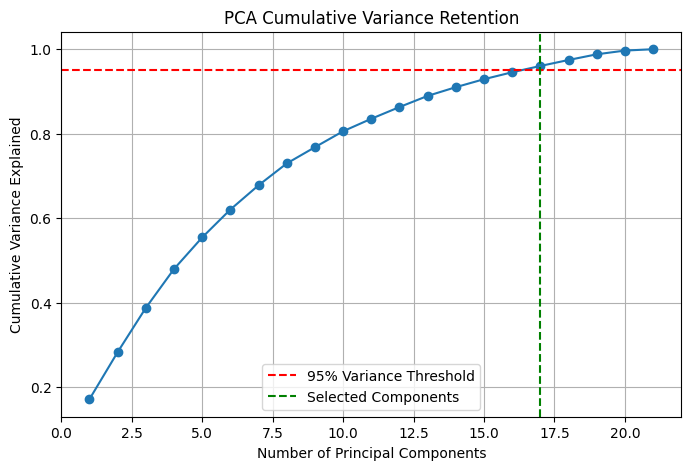

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer
import pandas as pd

# Load your dataset (assuming already uploaded to Colab as 'diabetes.csv')
df = pd.read_csv("diabetes.csv")

# Separate features and labels
target = 'Diabetes_012' if 'Diabetes_012' in df.columns else 'Diabetes_binary'
df2 = df.copy()
if target=='Diabetes_012': df2[target]=df2[target].replace(2,1)
X = df2.drop(columns=[target])  # Use df2 and the correct target column name
y = df2[target] # Use df2 and the correct target column name

# Apply quantile transformation (as in your preprocessing)
qt = QuantileTransformer(output_distribution='normal', random_state=SEED) # Use the same random_state as before
X_transformed = qt.fit_transform(X)

# Fit PCA
pca = PCA().fit(X_transformed)

# Cumulative variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Variance Threshold")
plt.axvline(x=(cumulative_variance >= 0.95).argmax()+1, color='g', linestyle='--', label="Selected Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Variance Retention")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-2242880957.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,


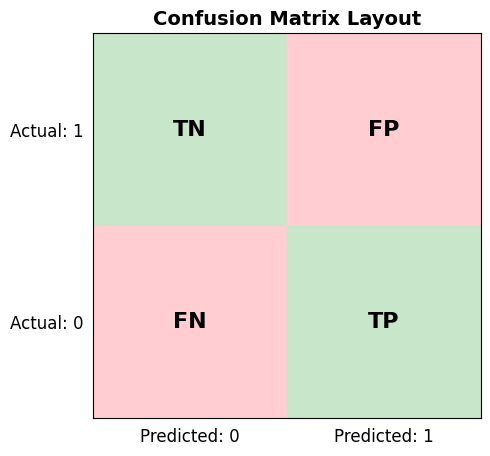

In [ ]:
import matplotlib.pyplot as plt

# Create confusion matrix layout
fig, ax = plt.subplots(figsize=(5,5))

# Define labels and colors
labels = [["TN", "FP"],
          ["FN", "TP"]]
colors = [["#C8E6C9", "#FFCDD2"],   # green for correct, red for incorrect
          ["#FFCDD2", "#C8E6C9"]]

# Draw the 2x2 grid
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                                   fill=True, color=colors[i][j], edgecolor="black"))
        ax.text(j+0.5, 1-i+0.5, labels[i][j], ha="center", va="center",
                fontsize=16, weight="bold")

# Format axes
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted: 0", "Predicted: 1"], fontsize=12)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual: 0", "Actual: 1"], fontsize=12)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
ax.set_title("Confusion Matrix Layout", fontsize=14, weight="bold")
ax.tick_params(left=False, bottom=False)

plt.show()


/tmp/ipython-input-1495766298.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,


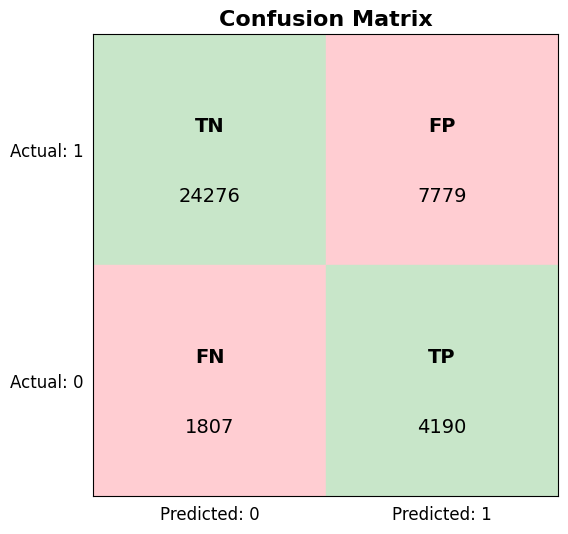

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your confusion matrix values
cm = np.array([[24276, 7779],
               [1807,  4190]])

# Labels for the cells
labels = [["TN", "FP"],
          ["FN", "TP"]]

# Colors: green for correct, red for incorrect
colors = [["#C8E6C9", "#FFCDD2"],
          ["#FFCDD2", "#C8E6C9"]]

fig, ax = plt.subplots(figsize=(6,6))

# Draw the grid with numbers + labels
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                                   fill=True, color=colors[i][j], edgecolor="black"))
        ax.text(j+0.5, 1-i+0.6, labels[i][j], ha="center", va="center", fontsize=14, weight="bold")
        ax.text(j+0.5, 1-i+0.3, f"{cm[i,j]}", ha="center", va="center", fontsize=14)

# Format axes
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted: 0", "Predicted: 1"], fontsize=12)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual: 0", "Actual: 1"], fontsize=12)
ax.set_xlim(0,2)
ax.set_ylim(0,2)
ax.set_title("Confusion Matrix", fontsize=16, weight="bold")
ax.tick_params(left=False, bottom=False)

plt.show()


/tmp/ipython-input-1955278322.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,


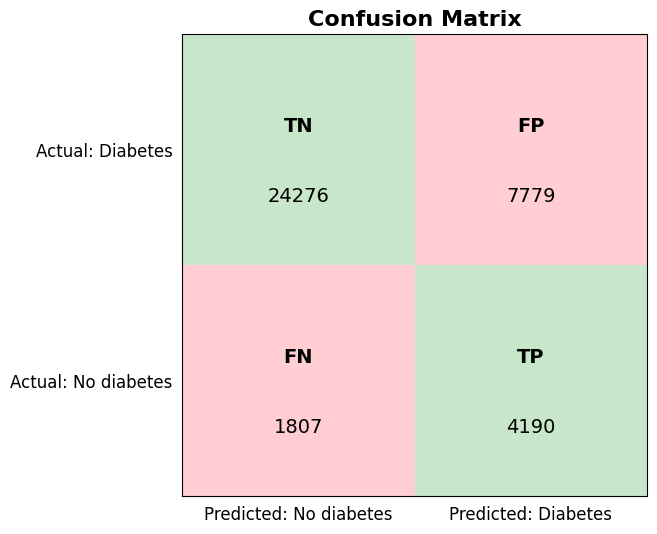

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your confusion matrix values
cm = np.array([[24276, 7779],
               [1807,  4190]])

# Labels for the cells
labels = [["TN", "FP"],
          ["FN", "TP"]]

# Colors: green for correct, red for incorrect
colors = [["#C8E6C9", "#FFCDD2"],
          ["#FFCDD2", "#C8E6C9"]]

fig, ax = plt.subplots(figsize=(6,6))

# Draw the grid with numbers + labels
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                                   fill=True, color=colors[i][j], edgecolor="black"))
        ax.text(j+0.5, 1-i+0.6, labels[i][j], ha="center", va="center", fontsize=14, weight="bold")
        ax.text(j+0.5, 1-i+0.3, f"{cm[i,j]}", ha="center", va="center", fontsize=14)

# Replace 0/1 with human-readable class labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted: No diabetes", "Predicted: Diabetes"], fontsize=12)
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual: No diabetes", "Actual: Diabetes"], fontsize=12)

ax.set_xlim(0,2)
ax.set_ylim(0,2)
ax.set_title("Confusion Matrix", fontsize=16, weight="bold")
ax.tick_params(left=False, bottom=False)

plt.show()
